In [12]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns

In [13]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


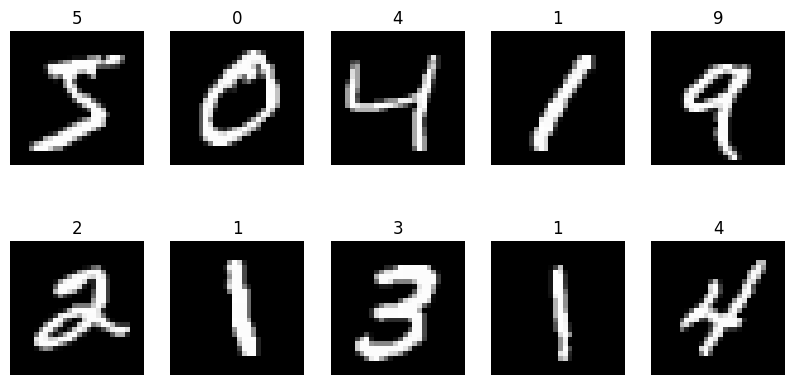

In [14]:
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap='gray')

    plt.title(y_train[i])

    plt.axis('off')

plt.show()

In [15]:
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [16]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [17]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

In [18]:
model = Sequential()

model.add(Conv2D(32,
                 (3,3),
                 activation='relu',
                 input_shape=(28,28,1)))

model.add(BatchNormalization())

model.add(MaxPooling2D(2,2))

model.add(Dropout(0.25))

model.add(Conv2D(64,
                 (3,3),
                 activation='relu'))

model.add(BatchNormalization())

model.add(MaxPooling2D(2,2))

model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(128,
                activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10,
                activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(

optimizer='adam',

loss='categorical_crossentropy',

metrics=['accuracy']

)

In [20]:
early_stop = EarlyStopping(

monitor='val_loss',

patience=5,

restore_best_weights=True

)

checkpoint = ModelCheckpoint(

'best_model.keras',

save_best_only=True

)

reduce_lr = ReduceLROnPlateau(

monitor='val_loss',

factor=0.2,

patience=3

)

In [21]:
history = model.fit(

X_train,

y_train,

epochs=20,

batch_size=128,

validation_split=0.2,

callbacks=[

early_stop,

checkpoint,

reduce_lr

]

)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 65s 166ms/step - accuracy: 0.8713 - loss: 0.4305 - val_accuracy: 0.7692 - val_loss: 0.7958 - learning_rate: 0.0010
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 60s 160ms/step - accuracy: 0.9535 - loss: 0.1540 - val_accuracy: 0.9840 - val_loss: 0.0544 - learning_rate: 0.0010
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 159ms/step - accuracy: 0.9672 - loss: 0.1110 - val_accuracy: 0.9860 - val_loss: 0.0466 - learning_rate: 0.0010
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 85s 167ms/step - accuracy: 0.9734 - loss: 0.0935 - val_accuracy: 0.9873 - val_loss: 0.0443 - learning_rate: 0.0010
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 60s 159ms/step - accuracy: 0.9747 - loss: 0.0829 - val_accuracy: 0.9892 - val_loss: 0.0429 - learning_rate: 0.0010
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 63s 168ms/step - accuracy: 0.9779 - loss: 0.0736 - val_accuracy: 0.9890 - val_loss: 0.0401 - learning_rate: 0.0010
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 60s 159ms/step - accuracy: 0.9

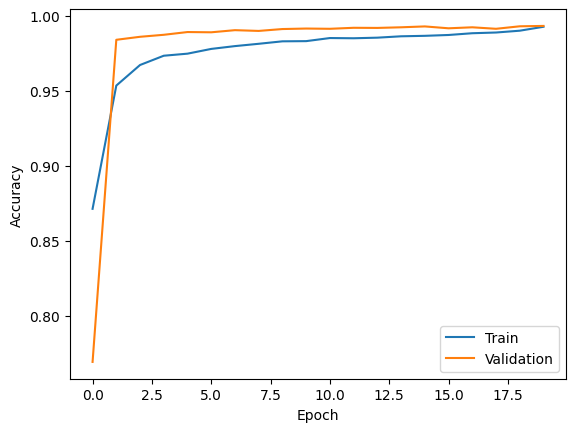

In [22]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

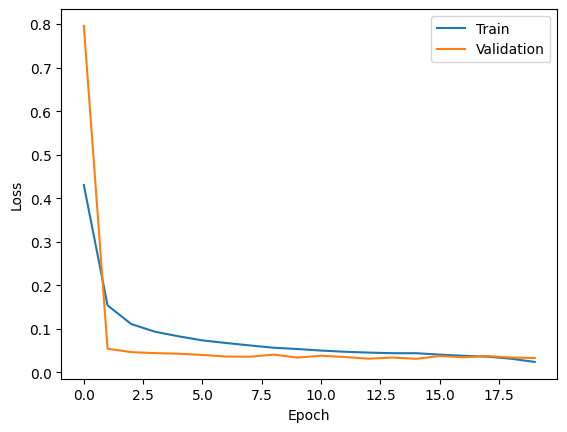

In [23]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [24]:
loss, accuracy = model.evaluate(

X_test,

y_test

)

print("Accuracy :",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9921 - loss: 0.0301
Accuracy : 0.9921000003814697


In [25]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions,axis=1)

true_labels = np.argmax(y_test,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


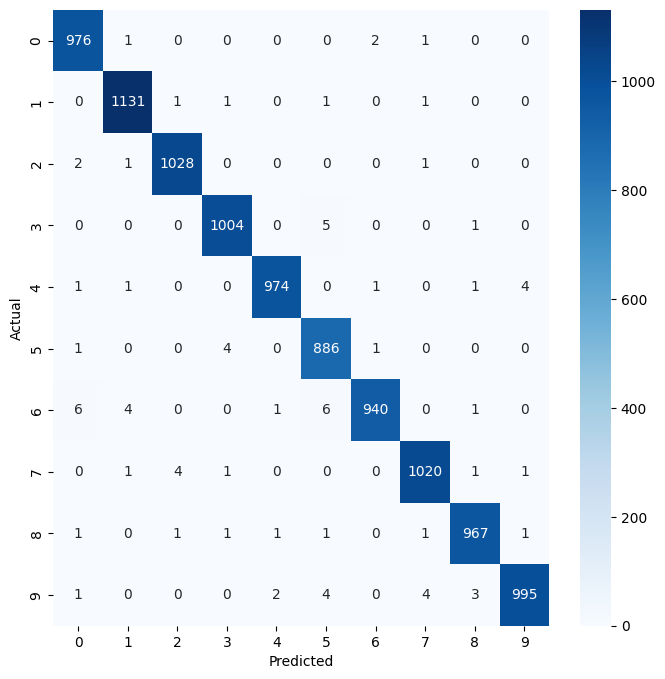

In [26]:
cm = confusion_matrix(

true_labels,

predicted_labels

)

plt.figure(figsize=(8,8))

sns.heatmap(

cm,

annot=True,

fmt='d',

cmap='Blues'

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [27]:
print(classification_report(

true_labels,

predicted_labels

))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      1.00      1.00      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [29]:
model.save("Digit_Recognition_Model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Prediction : 6


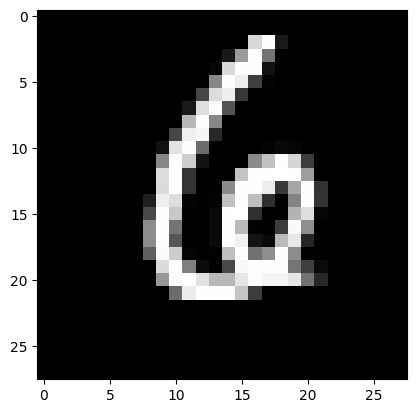

In [30]:
index = 123

plt.imshow(

X_test[index].reshape(28,28),

cmap='gray'

)

prediction = np.argmax(

model.predict(

X_test[index].reshape(1,28,28,1)

)

)

print("Prediction :",prediction)